In [1]:
log_path = 'training_log.txt'

In [2]:
# imports

import re
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pattern = re.compile(
    r'^(?P<epoch>\d+),(?P<loss>[^,]+),(?P<improvement>[^,]+),\[(?P<diversity>[^\]]+)\],\[(?P<pixel_diff>[^\]]+)\],\[(?P<ssim>[^\]]+)\],(?P<time_min>[^,\n]+)$'
)

labels = ['A', 'B', 'G']
metrics = ['ssim', 'diversity', 'pixel_diff']

rows = []
with open(log_path) as f:
    for line in f:
        line = line.strip()

         # skip header
        if not line or line.startswith('epoch'):
            continue
        m = pattern.match(line)

        if not m:
            continue
        def to_list(s):
            return [float(x.strip()) for x in s.split(',') if x.strip()]
        
        div = to_list(m.group('diversity'))
        pix = to_list(m.group('pixel_diff'))
        ssm = to_list(m.group('ssim'))
        if not (len(div) == len(pix) == len(ssm) == 3):
            continue
        rows.append({
            'epoch': int(m.group('epoch')),
            'diversity_A': div[0], 'diversity_B': div[1], 'diversity_G': div[2],
            'pixel_diff_A': pix[0], 'pixel_diff_B': pix[1], 'pixel_diff_G': pix[2],
            'ssim_A': ssm[0], 'ssim_B': ssm[1], 'ssim_G': ssm[2],
        })

df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)
df.tail(3)

,epoch,diversity_A,diversity_B,diversity_G,pixel_diff_A,pixel_diff_B,pixel_diff_G,ssim_A,ssim_B,ssim_G
17,18,0.4157,0.4157,0.4161,0.5025,0.5015,0.5003,0.0002,0.0003,0.0005
18,19,0.4158,0.4155,0.4156,0.5025,0.5022,0.4997,0.0003,0.0002,0.0005
19,20,0.4154,0.4162,0.4162,0.5032,0.5011,0.4989,0.0002,0.0004,0.0007


In [4]:
# ensure dataframe is in the correct shape

df.shape[0] == 60

False

### Diversity Score Over Ecpochs

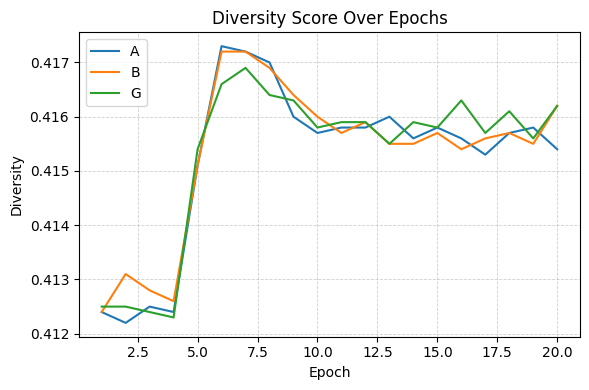

In [5]:
# plot the observations of diversity score

plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'diversity_{lab}'], label=lab)
plt.xlabel('Epoch')
plt.ylabel('Diversity')
plt.title('Diversity Score Over Epochs')
plt.legend()
plt.legend()
plt.grid(linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

### Pixel-level Difference Over Epochs

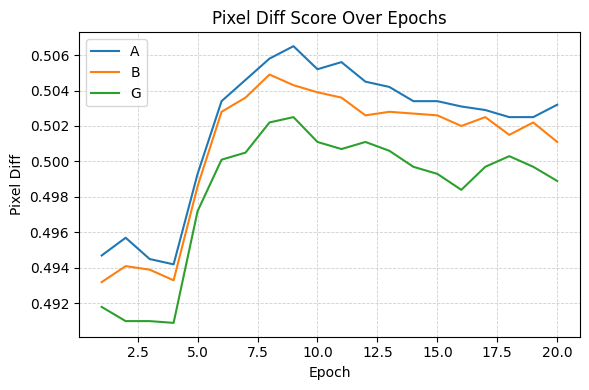

In [6]:
# plot the observations of pixel level difference
plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'pixel_diff_{lab}'], label=lab)
plt.xlabel('Epoch')
plt.ylabel('Pixel Diff')
plt.title('Pixel Diff Score Over Epochs')
plt.legend()
plt.grid(linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

### SSIM Score Over Epochs

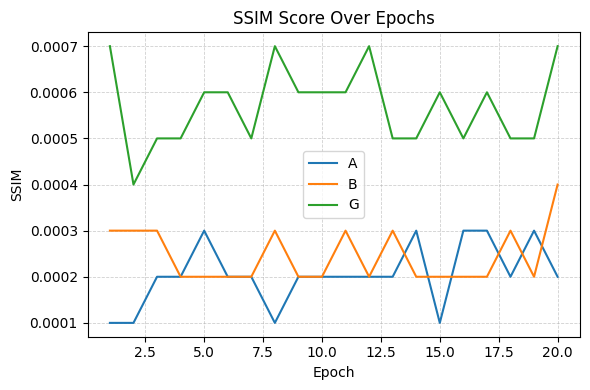

In [7]:
# plot the observations of SSIM score

plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'ssim_{lab}'], label=lab)
plt.xlabel('Epoch')
plt.ylabel('SSIM')
plt.title('SSIM Score Over Epochs')
plt.legend()
plt.legend()
plt.grid(linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

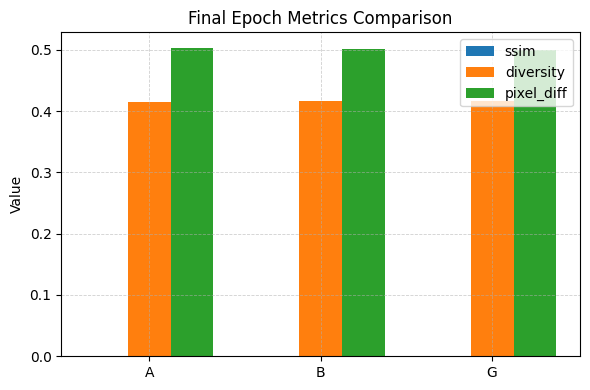

In [8]:
# final epoch comparison

import numpy as np
final = df.iloc[-1]
bar_labels = labels
x = np.arange(len(bar_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(6,4))
for i, metric in enumerate(metrics):
    ax.bar(x + (i-1)*width, [final[f'{metric}_{lab}'] for lab in bar_labels], width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.set_ylabel('Value')
ax.set_title('Final Epoch Metrics Comparison')
ax.legend()
plt.legend()
plt.grid(linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/y6/v08pgd9n6f32p2hsb0h872_h0000gn/T/ipykernel_6906/758724758.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


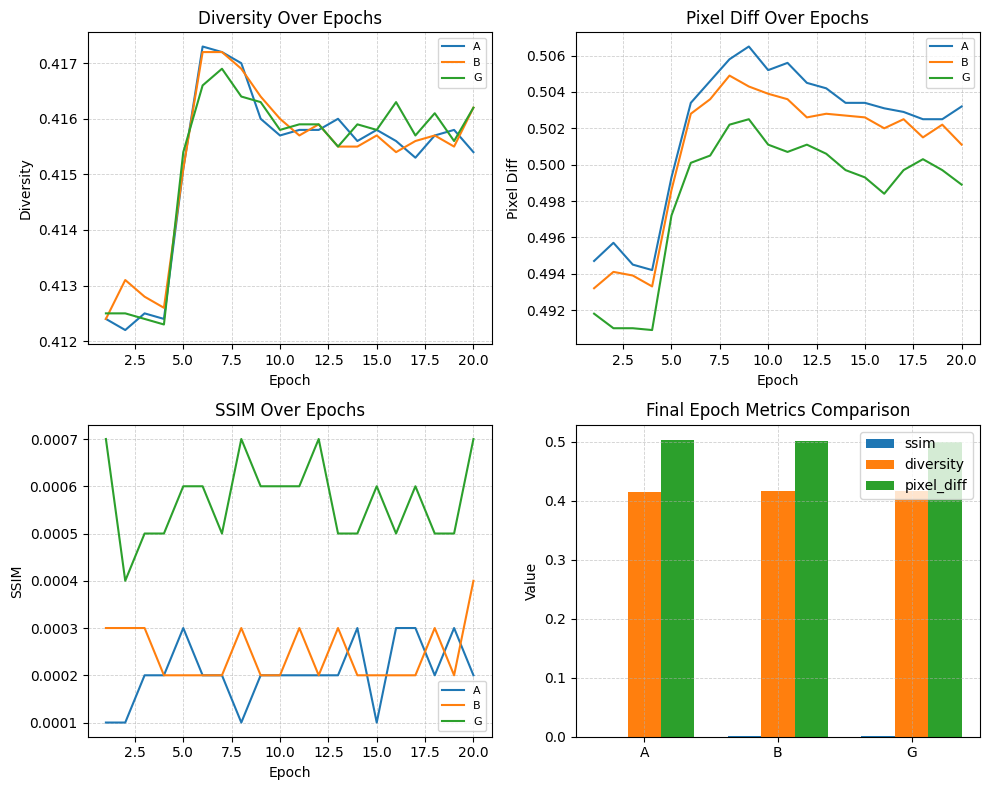

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
(ax_div, ax_pix), (ax_ssim, ax_bar) = axes

# helper to plot a line chart for a metric across epochs for all classes
def plot_metric_lines(ax, metric_key, title, ylabel):
    for lab in labels:
        ax.plot(df['epoch'], df[f'{metric_key}_{lab}'], label=lab)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.grid(linestyle='--', linewidth=0.6, alpha=0.6)
    ax.legend(fontsize=8)
    plt.legend()

plot_metric_lines(ax_div, 'diversity', 'Diversity Over Epochs', 'Diversity')
plot_metric_lines(ax_pix, 'pixel_diff', 'Pixel Diff Over Epochs', 'Pixel Diff')
plot_metric_lines(ax_ssim, 'ssim', 'SSIM Over Epochs', 'SSIM')


final = df.iloc[-1]
bar_labels = labels
x = np.arange(len(bar_labels))
width = 0.25
for i, metric in enumerate(metrics):
    ax_bar.bar(
        x + (i-1)*width,
        [final[f'{metric}_{lab}'] for lab in bar_labels],
        width,
        label=metric,
        edgecolor='none'
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_labels)
ax_bar.set_ylabel('Value')
ax_bar.set_title('Final Epoch Metrics Comparison')
ax_bar.legend(fontsize=8)
plt.legend()
plt.legend()
plt.grid(linestyle='--', linewidth=0.6, alpha=0.6)
plt.tight_layout()
plt.show()

### Rsults of Final Epoch

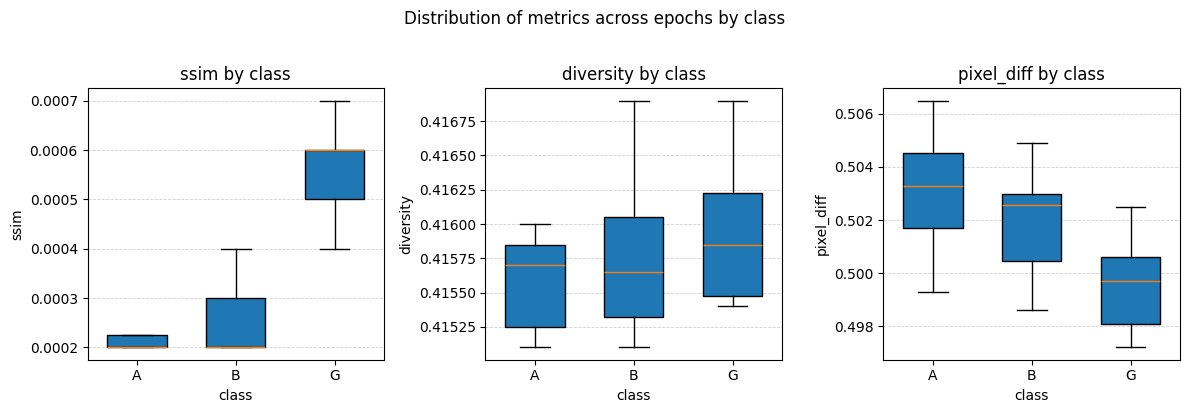

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, metric in zip(axes, metrics):

    # collect data per class across epochs
    data = [df[f"{metric}_{lab}"].dropna().values for lab in labels]
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        widths=0.6,
        patch_artist=True,
        showfliers=False,

    )
    ax.set_title(f"{metric} by class")
    ax.set_xlabel("class")
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)

plt.suptitle("Distribution of metrics across epochs by class", y=1.02)
plt.tight_layout()
plt.show()

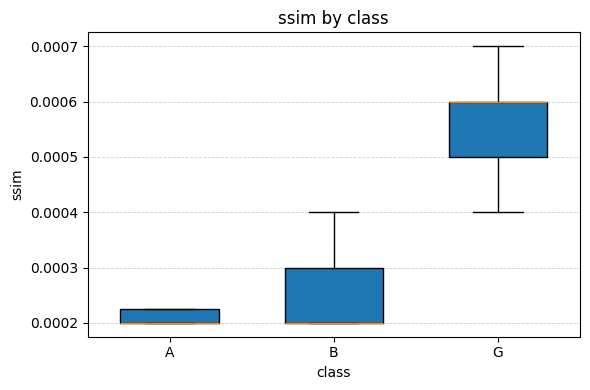

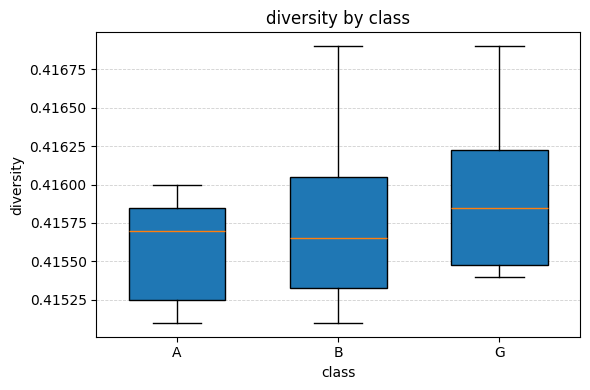

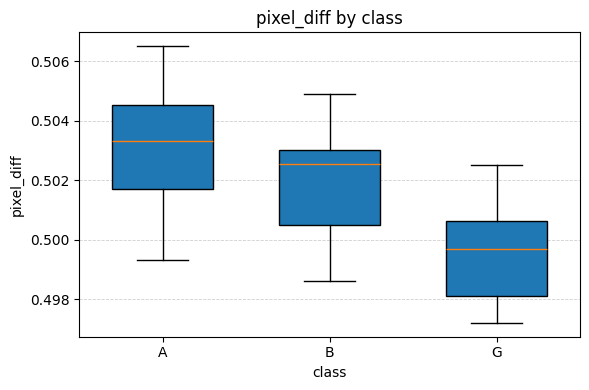

In [11]:
for metric in metrics:
    plt.figure(figsize=(6, 4))
    data = [df[f"{metric}_{lab}"].dropna().values for lab in labels]
    plt.boxplot(
        data,
        tick_labels=labels,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
    )
    plt.title(f"{metric} by class")
    plt.xlabel("class")
    plt.ylabel(metric)
    plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    plt.tight_layout()
    plt.show()